In [5]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/1_methods_desc/")
FIG_DIR.mkdir(parents=True, exist_ok=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [2]:
""" Load data """

from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    load_eog=False,
)


EOG data not full for 16, 1 (0/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (0/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (0/427). Skipping


# Figure B: Pattern Analysis

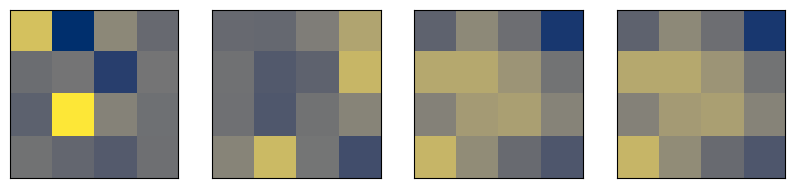

In [6]:
"""
Plot similar and different matrices for the analysis figure 
"""

import numpy as np
from scipy.stats import rankdata
from matplotlib import pyplot as plt



def correlated_matrices(rho, size=4, value_range=(0, 1), seed=None):
    """
    Two `size` x `size` matrices with entries bounded in `value_range`
    and flattened Pearson/Spearman correlation near `rho`.

    Construction:
      1. Draw A, noise ~ N(0, 1), standardized.
      2. B = rho * A + sqrt(1 - rho^2) * noise.
      3. Map each matrix to uniform ranks in [0, 1], then scale to range.
         This bounds outputs exactly and preserves rank correlation.
    """
    if not -1 <= rho <= 1:
        raise ValueError("rho must be in [-1, 1].")
    low, high = value_range
    if high <= low:
        raise ValueError("value_range must be (low, high) with high > low.")

    rng = np.random.default_rng(seed)

    def standardize(x):
        return (x - x.mean()) / x.std()

    A = standardize(rng.standard_normal((size, size)))
    noise = standardize(rng.standard_normal((size, size)))
    B = rho * A + np.sqrt(1 - rho**2) * noise

    def to_range(x):
        # Rank-based mapping -> uniform on (0, 1), then rescale.
        # Using (rank - 0.5) / n puts values strictly inside (0, 1).
        n = x.size
        u = (rankdata(x, method="average").reshape(x.shape) - 0.5) / n
        return low + u * (high - low)

    return to_range(A), to_range(B)


# Plot different matrices
vmin = -3
vmax = 3
cmap = "cividis"

f, axs = plt.subplots(1,4, figsize=(10,5),subplot_kw={'xticks': [], 'yticks': []})

seed = 3 # int(random()*10)
rng = np.random.default_rng(seed)
A = rng.standard_normal((4, 4))
axs[0].imshow(A, cmap=cmap, vmin=vmin, vmax=vmax)

seed *=17
rng = np.random.default_rng(seed)
B = rng.standard_normal((4, 4))
axs[1].imshow(B, cmap=cmap, vmin=vmin, vmax=vmax)

rng = np.random.default_rng(seed*17)
C = rng.standard_normal((4, 4)) 
axs[2].imshow(C, cmap=cmap, vmin=vmin, vmax=vmax)
axs[3].imshow(C, cmap=cmap, vmin=vmin, vmax=vmax)
plt.savefig(FIG_DIR / "similarity_matrices.svg", dpi=300)

# Figure C: Single-participant example

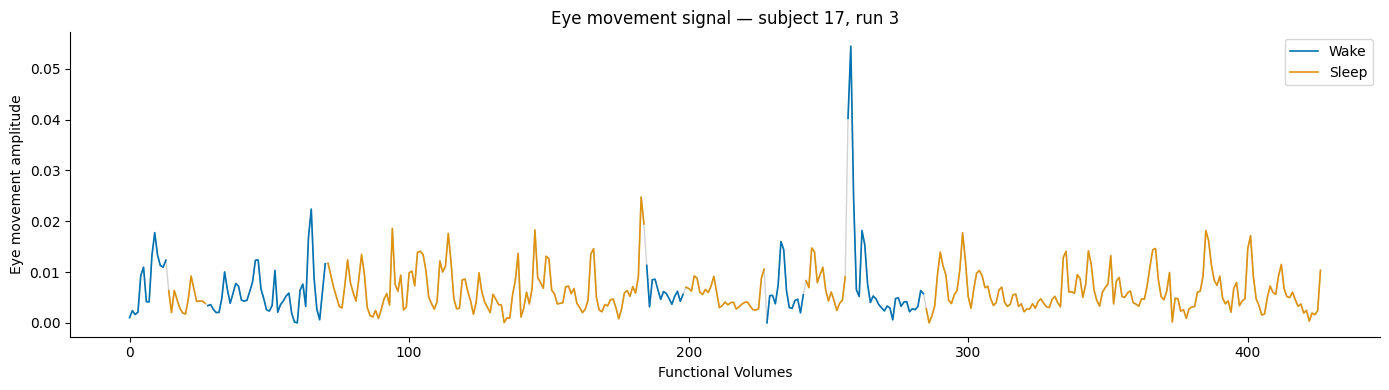

In [7]:
""" 
This subject just looked good for the figure layout
"""


import numpy as np
from matplotlib import pyplot as plt

subject = "17"
run = 3

df = mrio.events
df = df[(df["subject"]==subject) & (df["run"]==run)]
eye_signal, _ = mrio.load_eye_move(subject, run)


fig, ax = plt.subplots(figsize=(14, 4))

time = np.arange(len(eye_signal))

# Plot full signal in gray as baseline
ax.plot(time, eye_signal, color='lightgray', linewidth=1, zorder=1)

# Overlay colored segments by state
state_colors = {
    'W': ("#0173b2ff", "Wake"),
    # '1': ("#E8A44C", "N1"),
    # '2': ("#6DBE6D", "N2"),
    'S': ("#de8f05f2", "Sleep")
}

for label, (color, name) in state_colors.items():
    if label not in df.columns:
        continue
    mask = df[label].values.astype(bool)
    # Plot only the masked timepoints
    masked_signal = np.where(mask, eye_signal, np.nan)
    ax.plot(time, masked_signal, color=color, linewidth=1.2, label=name, zorder=2)

ax.set_xlabel("Functional Volumes")
ax.set_ylabel("Eye movement amplitude")
ax.set_title(f"Eye movement signal — subject {subject}, run {run}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / "ideal_run.svg", dpi=300)

# Figure D: Preprocessing Steps

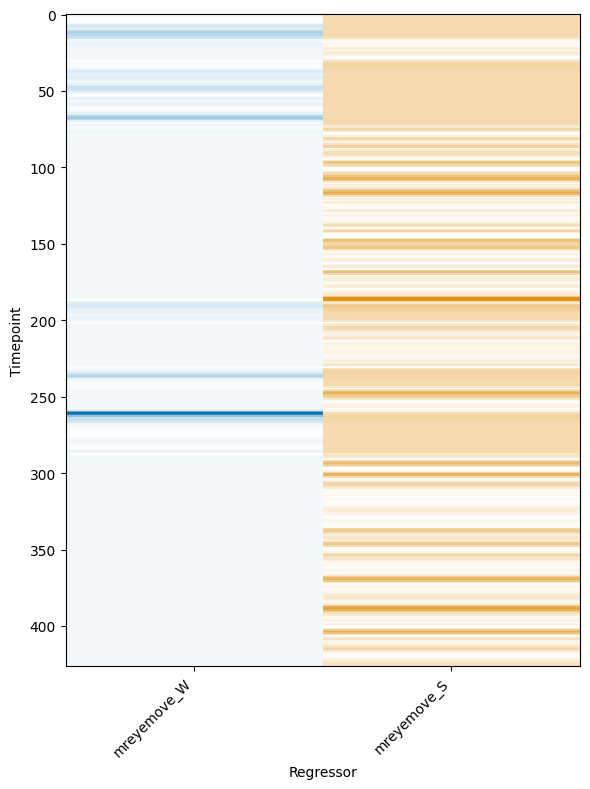

In [8]:
"""
Create two regressors for the preprocessing figure
"""

from matplotlib.colors import LinearSegmentedColormap
from mreyemove.analysis.glm.first_level import build_design_matrix
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from matplotlib import pyplot as plt

subject = "17"
run = 3

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
df = mrio.events 
run_events = df[(df["subject"] == subject) & (df["run"] == run)]

X = build_design_matrix(
    dataset=mrio,
    subject=subject,
    run=run,
    run_events=run_events,
    config=config,
)



def make_cmap(hex_color, background="white", name=None):
    """White (or other bg) -> hex_color colormap."""
    return LinearSegmentedColormap.from_list(
        name or hex_color, [background, hex_color]
    )


use_abs = True
n_reg = 0
hex_colors = ["#0173b2ff", "#de8f05f2",] + ["#888888"] * (n_reg - 2)

fig, ax = plt.subplots(figsize=(6, 8))
X = X.iloc[:, 0:2+n_reg]
n_tp, n_reg = X.shape

cmaps = [make_cmap(c) for c in hex_colors]



for i, (col, cmap) in enumerate(zip(X.columns, cmaps)):
    vals = X[col].values
    data = np.abs(vals) if use_abs else vals
    vmax = np.abs(vals).max() or 1.0  # avoid vmax=0 for empty cols
    ax.imshow(
        data[:, None],
        aspect="auto",
        cmap=cmap,
        vmin=0 if use_abs else -vmax,
        vmax=vmax,
        extent=(i - 0.5, i + 0.5, n_tp - 0.5, -0.5),
        interpolation="nearest",
    )

ax.set_xlim(-0.5, n_reg - 0.5)
ax.set_ylim(n_tp - 0.5, -0.5)
ax.set_xticks(range(n_reg))
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.set_xlabel("Regressor")
ax.set_ylabel("Timepoint")
plt.tight_layout()

fig.savefig(FIG_DIR / "ideal_run_design.svg", dpi=300)